# Análisis de Finanzas y Riesgo Crediticio 020226

## Librerias

In [104]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from optbinning import OptimalBinning

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.tree import plot_tree
from scipy.stats import chi2_contingency



## 1. Cargar dataset

In [3]:
# Ruta CSV 
data_path = "../Data/Silver_BANK_marketing_020226.csv"

# Cargar el dataset
df = pd.read_csv(
    data_path,
    sep=",",
    encoding="utf-8"
)

# Verificar dimensiones iniciales
df.shape


(11150, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11150 entries, 0 to 11149
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         11150 non-null  int64  
 1   age        11150 non-null  int64  
 2   job        11150 non-null  object 
 3   marital    11150 non-null  object 
 4   education  11150 non-null  object 
 5   default    11150 non-null  int64  
 6   balance    11150 non-null  float64
 7   housing    11150 non-null  int64  
 8   loan       11150 non-null  int64  
 9   contact    11150 non-null  object 
 10  day        11150 non-null  int64  
 11  month      11150 non-null  object 
 12  duration   11150 non-null  int64  
 13  campaign   11150 non-null  int64  
 14  pdays      11150 non-null  int64  
 15  previous   11150 non-null  int64  
 16  poutcome   11150 non-null  object 
 17  deposit    11150 non-null  int64  
dtypes: float64(1), int64(11), object(6)
memory usage: 1.5+ MB


## 2. Análisis de variables relevantes

### 2.1. Balance

In [5]:
# Estadísticas descriptivas ampliadas de balance
df["balance"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99])


count    11150.000000
mean      1529.499462
std       3226.792753
min      -6847.000000
1%        -522.000000
5%         -54.000000
10%          0.000000
25%        123.000000
50%        550.000000
75%       1709.750000
90%       3899.300000
95%       6027.000000
99%      13248.820000
max      81204.000000
Name: balance, dtype: float64

### 2.2. Credit default

In [6]:
df = df.rename(columns={"default": "credit_default"})


In [7]:
# Conteo y %
df["credit_default"].value_counts(), df["credit_default"].value_counts(normalize=True) * 100

(credit_default
 0    10982
 1      168
 Name: count, dtype: int64,
 credit_default
 0    98.493274
 1     1.506726
 Name: proportion, dtype: float64)

## 3. Optimal Binning de Balance

In [8]:

x = df["balance"]
y = df["credit_default"]

optb = OptimalBinning(
    name="balance",
    dtype="numerical",
    solver="mip"
)

optb.fit(x, y)

optb.splits
optb.binning_table.build()


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, -0.50)",686,0.061525,608,78,0.113703,-2.126583,0.869607,0.091959
1,"[-0.50, 17.50)",1085,0.097309,1047,38,0.035023,-0.863951,0.113050,0.013708
2,"[17.50, 86.50)",689,0.061794,671,18,0.026125,-0.561651,0.025860,0.003191
3,"[86.50, 162.50)",685,0.061435,679,6,0.008759,0.548813,0.014332,0.001769
4,"[162.50, 339.50)",1327,0.119013,1316,11,0.008289,0.604408,0.032853,0.004045
5,"[339.50, 457.50)",650,0.058296,647,3,0.004615,1.193685,0.049010,0.005787
6,"[457.50, 1238.50)",2483,0.222691,2472,11,0.004430,1.234839,0.197104,0.023183
7,"[1238.50, 1579.50)",560,0.050224,559,1,0.001786,2.146101,0.096465,0.010173
8,"[1579.50, 3155.50)",1486,0.133274,1485,1,0.000673,3.123121,0.403722,0.036591
9,"[3155.50, inf)",1499,0.134439,1498,1,0.000667,3.131837,0.408556,0.036976


#### ¿Qué significan las columnas del binning?

- **Bin:** Intervalo de valores de saldo creado por el algoritmo.
- **Count:** Número de clientes en cada intervalo.
- **Non-event / Event:** Clientes sin default vs con default.
- **Event rate:** % de clientes con default dentro del bin.
- **WoE (Weight of Evidence):** Medida del poder discriminante: positivo indica que el bin separa bien las clases respecto al global.
- **IV (Information Value):** Indicador global de poder predictivo de la variable. Valores altos (ej. >0.5) indican alto poder. 
- **JS:** Métrica adicional de separación entre distribuciones de event/no-event.


#### Conclusión del binning

- La segmentación del saldo mediante optimal binning muestra que los clientes con saldos más bajos presentan tasas de impago significativamente más elevadas.
- No se identifican umbrales abruptos en la relación entre el saldo y el default. En su lugar, se observa una disminución gradual y consistente de la tasa de impago a medida que el saldo aumenta.
- Estos resultados indican que el saldo posee un fuerte poder discriminante y que los tramos identificados pueden utilizarse como umbrales operativos para el diseño de políticas de gestión del riesgo de crédito.

### 3.1 Visualizaciones

#### A) Event Rate por Bin

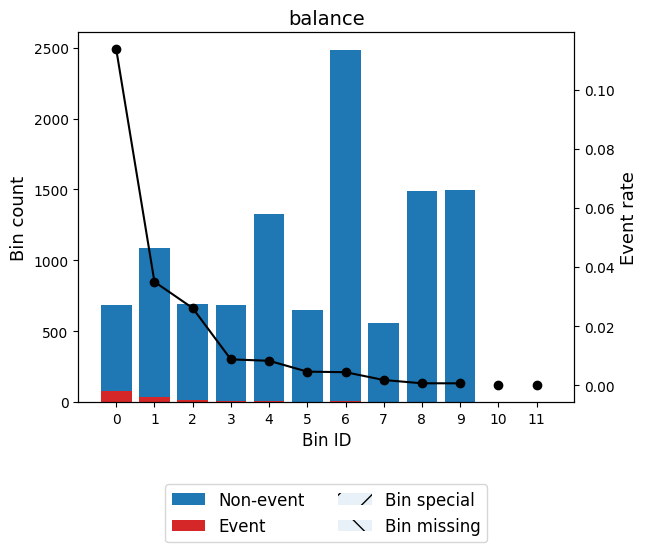

In [9]:
optb.binning_table.plot(metric="event_rate")

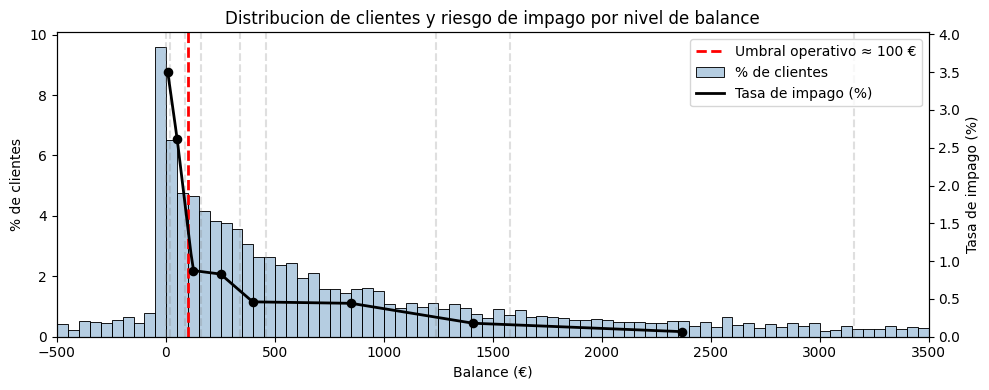

In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Limites de visualizacion
x_min = -500
x_max = 3500

# Binning table
bt = optb.binning_table.build()
bt = bt[bt["Bin"].str.contains("inf|\\[")].copy()

# Extraer limites del bin
def bin_limits(bin_str):
    left, right = bin_str.replace("[", "").replace(")", "").split(",")
    left = float(left) if "inf" not in left else np.nan
    right = float(right) if "inf" not in right else np.nan
    return left, right

bt[["bin_left", "bin_right"]] = bt["Bin"].apply(
    lambda x: pd.Series(bin_limits(x))
)

# Punto representativo del bin
bt["bin_point"] = (bt["bin_left"] + bt["bin_right"]) / 2

# Tasa de impago en porcentaje real
bt["event_rate_pct"] = bt["Event rate"] * 100

# Datos de balance en rango operativo
balance_zoom = df.loc[
    (df["balance"] >= x_min) & (df["balance"] <= x_max),
    "balance"
]

# -------------------------------
# FIGURA Y EJE PRINCIPAL
# -------------------------------
fig, ax1 = plt.subplots(figsize=(10, 4))

# Distribucion de clientes (%)
sns.histplot(
    balance_zoom,
    bins=80,
    stat="percent",
    color="steelblue",
    alpha=0.40,
    ax=ax1,
    label="% de clientes"
)

ax1.set_xlim(x_min, x_max)
ax1.set_xlabel("Balance (€)")
ax1.set_ylabel("% de clientes")

# Lineas verticales de bins
for x in bt["bin_right"].dropna():
    if x_min <= x <= x_max:
        ax1.axvline(x, color="grey", alpha=0.25, linestyle="--")

# Umbral operativo
ax1.axvline(
    100,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Umbral operativo ≈ 100 €"
)

# -------------------------------
# SEGUNDO EJE: TASA DE IMPAGO
# -------------------------------
x_bins = bt["bin_point"].values
y_bins = bt["event_rate_pct"].values

mask = ~np.isnan(x_bins) & ~np.isnan(y_bins)
x_bins = x_bins[mask]
y_bins = y_bins[mask]

interp_fn = interp1d(x_bins, y_bins, kind="linear", bounds_error=False)
x_smooth = np.linspace(x_bins.min(), x_bins.max(), 200)
y_smooth = interp_fn(x_smooth)

ax2 = ax1.twinx()

ax2.plot(
    x_smooth,
    y_smooth,
    color="black",
    linewidth=2,
    label="Tasa de impago (%)"
)

ax2.scatter(
    x_bins,
    y_bins,
    color="black",
    s=35,
    zorder=5
)

ax2.set_ylabel("Tasa de impago (%)")
ax2.set_ylim(0, y_bins.max() * 1.15)

# -------------------------------
# LEYENDA Y TITULO
# -------------------------------
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper right"
)

plt.title("Distribucion de clientes y riesgo de impago por nivel de balance")
plt.tight_layout()
plt.show()


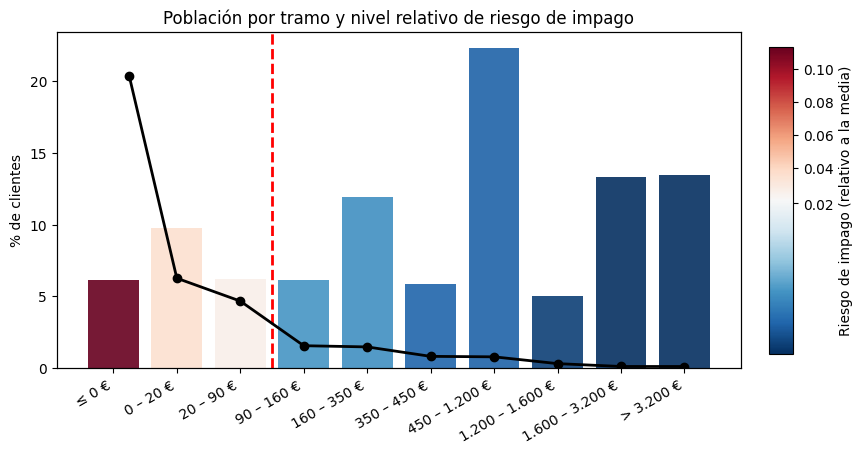

In [ ]:


# -----------------------
# Binning table
# -----------------------
bt = optb.binning_table.build()
bt_plot = bt[bt["Bin"].str.contains("inf|\\[")].copy()

bin_labels = [
    "≤ 0 €",
    "0 – 20 €",
    "20 – 90 €",
    "90 – 160 €",
    "160 – 350 €",
    "350 – 450 €",
    "450 – 1.200 €",
    "1.200 – 1.600 €",
    "1.600 – 3.200 €",
    "> 3.200 €"
]

x = np.arange(len(bt_plot))
client_pct = bt_plot["Count (%)"] * 100
impago_pct = bt_plot["Event rate"] * 100

# -----------------------
# Color scale
# -----------------------
mean_event_rate = bt_plot["Event rate"].mean()

norm = mcolors.TwoSlopeNorm(
    vmin=bt_plot["Event rate"].min(),
    vcenter=mean_event_rate,
    vmax=bt_plot["Event rate"].max()
)

cmap = plt.cm.RdBu_r
colors = cmap(norm(bt_plot["Event rate"]))

# -----------------------
# FIGURA + AXES
# -----------------------
fig = plt.figure(figsize=(9.5, 4.8))

# Axes principal
ax = fig.add_axes([0.08, 0.15, 0.72, 0.7])

# Barras: % de clientes
ax.bar(
    x,
    client_pct,
    color=colors,
    alpha=0.9
)

# Umbral operativo ~100 €
ax.axvline(
    2.5,
    color="red",
    linestyle="--",
    linewidth=2
)

ax.set_ylabel("% de clientes")
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=30, ha="right")
ax.set_title("Población por tramo y nivel relativo de riesgo de impago")

# -----------------------
# Linea: tasa de impago
# -----------------------
ax2 = ax.twinx()

x_line = x.astype(float)
x_line[0] += 0.25  # micro-shift estetico primer bin

ax2.plot(
    x_line,
    impago_pct,
    color="black",
    marker="o",
    linewidth=2
)

ax2.set_ylim(0, impago_pct.max() * 1.15)
ax2.set_yticks([])

# -----------------------
# COLORBAR EN AXES SEPARADO (FUERA)
# -----------------------
cax = fig.add_axes([0.83, 0.18, 0.025, 0.64])

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Riesgo de impago (relativo a la media)")

plt.show()


#### B) WoE (Weight of Evidence) por Bin

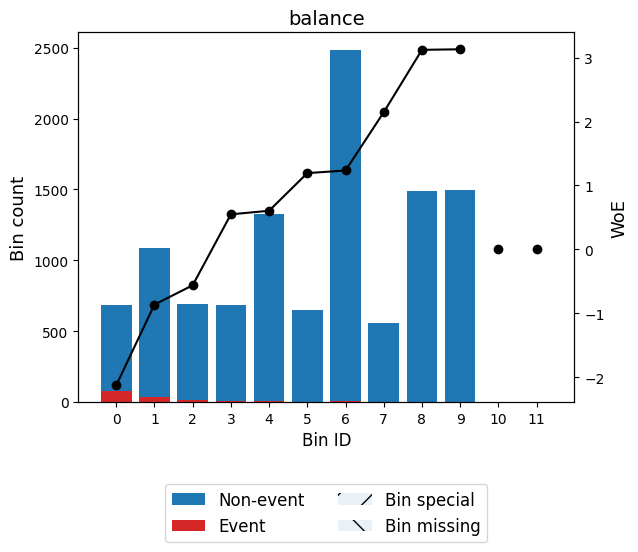

In [10]:
optb.binning_table.plot(metric="woe")


## 4. Validación y comparación de métodos

### 4.1. Comparación con método Tree (CART)

El árbol CART identifica varios puntos de corte del saldo a partir de los cuales cambia la composición entre clientes con y sin impago. 
Los principales umbrales se sitúan alrededor de −0.5, 17.5, 86.5 y 1238.5, lo que indica que el riesgo no evoluciona de forma lineal a lo largo del balance.

En los niveles de saldo más bajos, especialmente en valores negativos o próximos a cero, se observa una mayor proporción de impagos. A medida que el saldo aumenta, la presencia de impagos se reduce de forma clara y progresiva, hasta volverse residual en los tramos de saldo más elevados.

El árbol proporciona así una segmentación simple e intuitiva que permite identificar las zonas del balance donde el riesgo de morosidad cambia de manera más relevante.



In [11]:


tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=300,
    random_state=42
)

tree.fit(df[["balance"]], df["credit_default"])



,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,300
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:

print(export_text(tree, feature_names=["balance"]))


|--- balance <= -0.50
|   |--- balance <= -273.50
|   |   |--- class: 0
|   |--- balance >  -273.50
|   |   |--- class: 0
|--- balance >  -0.50
|   |--- balance <= 86.50
|   |   |--- balance <= 17.50
|   |   |   |--- class: 0
|   |   |--- balance >  17.50
|   |   |   |--- class: 0
|   |--- balance >  86.50
|   |   |--- balance <= 1238.50
|   |   |   |--- class: 0
|   |   |--- balance >  1238.50
|   |   |   |--- class: 0



Cada nodo del árbol divide las observaciones según si el balance cumple o no la condición indicada.


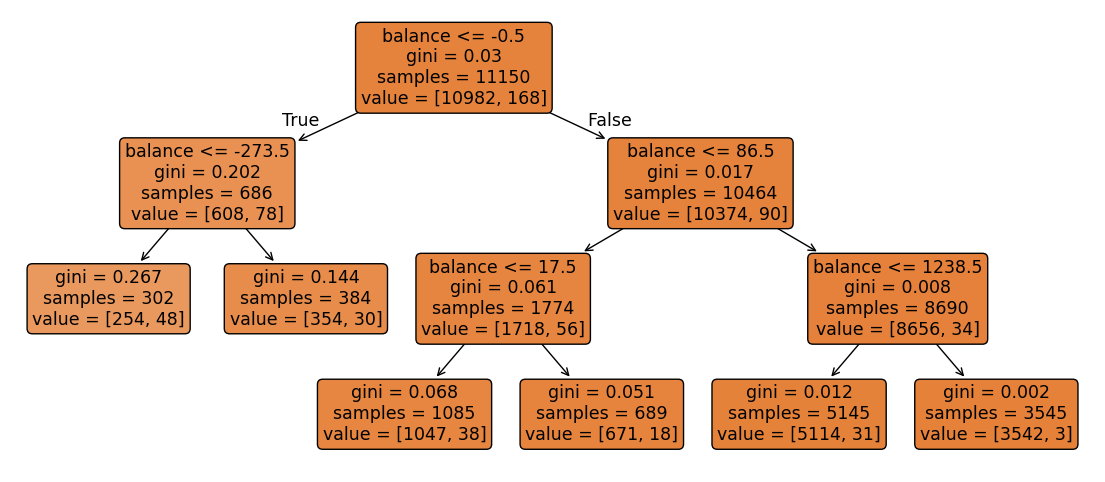

In [13]:
plt.figure(figsize=(14, 6))
plot_tree(
    tree,
    feature_names=["balance"],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.show()


### 4.2. Validación estadística con Chi-cuadrado

In [14]:
# Crear variable categórica de balance
df["balance_bin"] = optb.transform(df["balance"], metric="bins")


In [15]:
# Tabla de contingencia
contingency = pd.crosstab(
    df["balance_bin"],
    df["credit_default"]
)

contingency

credit_default,0,1
balance_bin,,
"(-inf, -0.50)",608,78
"[-0.50, 17.50)",1047,38
"[1238.50, 1579.50)",559,1
"[1579.50, 3155.50)",1485,1
"[162.50, 339.50)",1316,11
"[17.50, 86.50)",671,18
"[3155.50, inf)",1498,1
"[339.50, 457.50)",647,3
"[457.50, 1238.50)",2472,11


El test chi-cuadrado rechaza claramente la hipótesis de independencia entre los tramos de balance y el impago (p-value ≪ 0.05). Esto confirma que los bins definidos mediante optimal binning presentan diferencias estadísticamente significativas en la tasa de morosidad.


In [16]:
# Test Chi-cuadrado

chi2, p_value, dof, expected = chi2_contingency(contingency)

chi2, p_value


(np.float64(562.529076568769), np.float64(2.2910779563382086e-115))

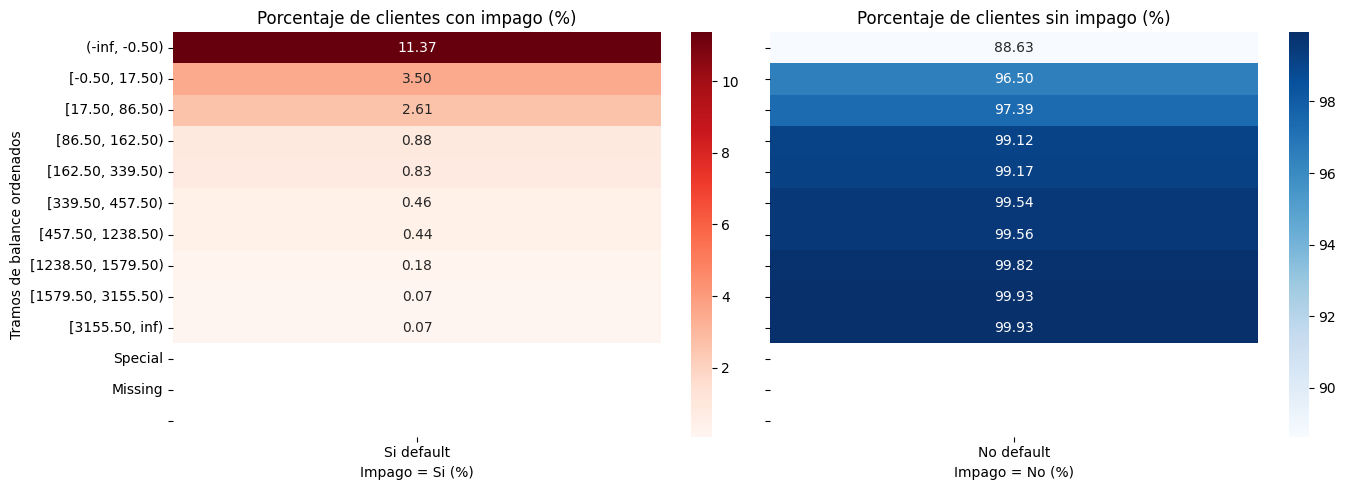

In [ ]:

# Copiar la tabla de contingencia original
cont = contingency.copy()

# Identificar automaticamente evento y no evento
event_col = cont.sum().idxmin()
nonevent_col = cont.sum().idxmax()

# Renombrar columnas a nombres claros
cont = cont.rename(
    columns={
        event_col: "Si default",
        nonevent_col: "No default"
    }
)

# Obtener el orden correcto de los bins desde el optimal binning
bin_order = optb.binning_table.build()["Bin"].values

# Reordenar la tabla de contingencia segun los bins
cont = cont.reindex(bin_order)

# Convertir conteos absolutos en porcentajes por fila
cont_pct = cont.div(cont.sum(axis=1), axis=0) * 100

# Crear figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Heatmap porcentaje de clientes con impago
sns.heatmap(
    cont_pct[["Si default"]],
    annot=True,
    fmt=".2f",
    cmap="Reds",
    ax=axes[0],
    cbar=True
)
axes[0].set_title("Porcentaje de clientes con impago (%)")
axes[0].set_xlabel("Impago = Si (%)")
axes[0].set_ylabel("Tramos de balance ordenados")

# Heatmap porcentaje de clientes sin impago
sns.heatmap(
    cont_pct[["No default"]],
    annot=True,
    fmt=".2f",
    cmap="Blues",
    ax=axes[1],
    cbar=True
)
axes[1].set_title("Porcentaje de clientes sin impago (%)")
axes[1].set_xlabel("Impago = No (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


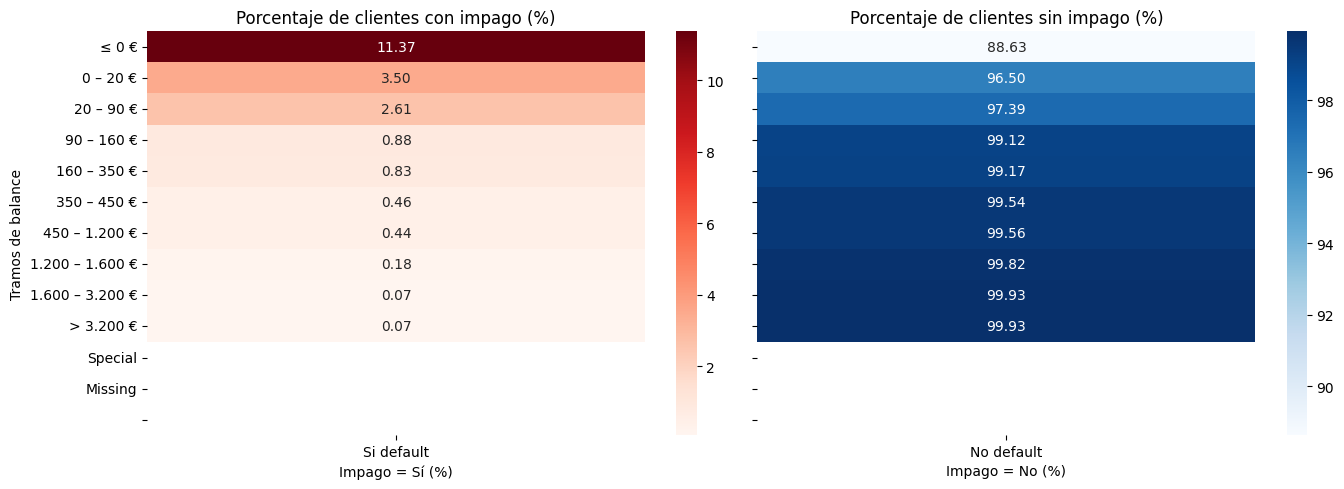

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------
# Copiar la tabla de contingencia
# -----------------------
cont = contingency.copy()

# Identificar evento / no evento
event_col = cont.sum().idxmin()
nonevent_col = cont.sum().idxmax()

cont = cont.rename(
    columns={
        event_col: "Si default",
        nonevent_col: "No default"
    }
)

# Orden de bins desde optimal binning
bin_order = optb.binning_table.build()["Bin"].values
cont = cont.reindex(bin_order)

# Convertir a porcentaje por fila
cont_pct = cont.div(cont.sum(axis=1), axis=0) * 100

# -----------------------
# MAPEO DE LABELS BUSINESS
# -----------------------
bin_label_map = {
    "(-inf, -0.50)": "≤ 0 €",
    "[-0.50, 17.50)": "0 – 20 €",
    "[17.50, 86.50)": "20 – 90 €",
    "[86.50, 162.50)": "90 – 160 €",
    "[162.50, 339.50)": "160 – 350 €",
    "[339.50, 457.50)": "350 – 450 €",
    "[457.50, 1238.50)": "450 – 1.200 €",
    "[1238.50, 1579.50)": "1.200 – 1.600 €",
    "[1579.50, 3155.50)": "1.600 – 3.200 €",
    "[3155.50, inf)": "> 3.200 €",
    "Special": "Special",
    "Missing": "Missing"
}

# Aplicar labels business SOLO donde existan
cont_pct.index = [
    bin_label_map.get(idx, idx) for idx in cont_pct.index
]

# -----------------------
# FIGURA
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Heatmap: clientes con impago
sns.heatmap(
    cont_pct[["Si default"]],
    annot=True,
    fmt=".2f",
    cmap="Reds",
    ax=axes[0],
    cbar=True
)
axes[0].set_title("Porcentaje de clientes con impago (%)")
axes[0].set_xlabel("Impago = Sí (%)")
axes[0].set_ylabel("Tramos de balance")

# Heatmap: clientes sin impago
sns.heatmap(
    cont_pct[["No default"]],
    annot=True,
    fmt=".2f",
    cmap="Blues",
    ax=axes[1],
    cbar=True
)
axes[1].set_title("Porcentaje de clientes sin impago (%)")
axes[1].set_xlabel("Impago = No (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


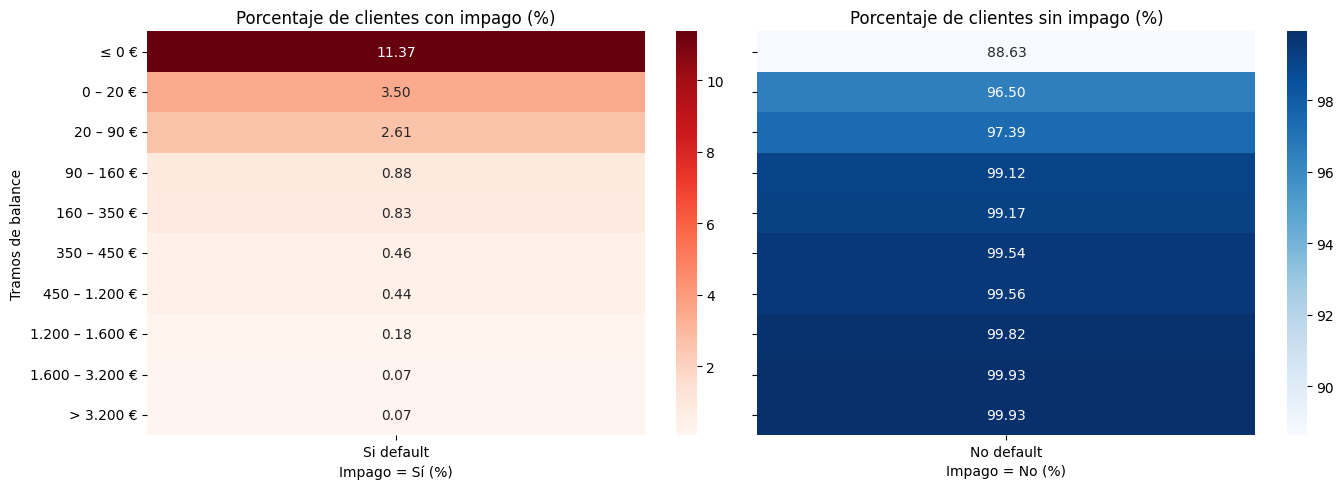

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------
# Copiar la tabla de contingencia
# -----------------------
cont = contingency.copy()

# Identificar evento / no evento
event_col = cont.sum().idxmin()
nonevent_col = cont.sum().idxmax()

cont = cont.rename(
    columns={
        event_col: "Si default",
        nonevent_col: "No default"
    }
)

# Orden de bins desde optimal binning
bin_order = optb.binning_table.build()["Bin"].values
cont = cont.reindex(bin_order)

# Eliminar filas vacías creadas por reindex
cont = cont.dropna(how="all")

# Eliminar Special y Missing
cont = cont.drop(index=["Special", "Missing"], errors="ignore")

# -----------------------
# Convertir a porcentaje por fila
# -----------------------
cont_pct = cont.div(cont.sum(axis=1), axis=0) * 100

# -----------------------
# MAPEO DE LABELS BUSINESS
# -----------------------
bin_label_map = {
    "(-inf, -0.50)": "≤ 0 €",
    "[-0.50, 17.50)": "0 – 20 €",
    "[17.50, 86.50)": "20 – 90 €",
    "[86.50, 162.50)": "90 – 160 €",
    "[162.50, 339.50)": "160 – 350 €",
    "[339.50, 457.50)": "350 – 450 €",
    "[457.50, 1238.50)": "450 – 1.200 €",
    "[1238.50, 1579.50)": "1.200 – 1.600 €",
    "[1579.50, 3155.50)": "1.600 – 3.200 €",
    "[3155.50, inf)": "> 3.200 €"
}

cont_pct.index = [
    bin_label_map.get(idx, idx) for idx in cont_pct.index
]

# -----------------------
# FIGURA
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Heatmap: clientes con impago
sns.heatmap(
    cont_pct[["Si default"]],
    annot=True,
    fmt=".2f",
    cmap="Reds",
    ax=axes[0],
    cbar=True
)
axes[0].set_title("Porcentaje de clientes con impago (%)")
axes[0].set_xlabel("Impago = Sí (%)")
axes[0].set_ylabel("Tramos de balance")

# Heatmap: clientes sin impago
sns.heatmap(
    cont_pct[["No default"]],
    annot=True,
    fmt=".2f",
    cmap="Blues",
    ax=axes[1],
    cbar=True
)
axes[1].set_title("Porcentaje de clientes sin impago (%)")
axes[1].set_xlabel("Impago = No (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()
